In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [9]:
class myLR:
    
    def __init(self):
        self.m = 0
        self.b = 0
    
    def fit(self, X_train, Y_train):
        num = 0
        den = 0

        X_mean = X_train.mean()
        Y_mean = Y_train.mean()
    
        for i in range(X_train.shape[0]):
            num += (X_train[i] - X_mean) * (Y_train[i] - Y_mean)
            den += (X_train[i] - X_mean) ** 2

        self.m = num/den
        self.b = Y_mean - (self.m * X_mean)

        print(self.m)
        print(self.b)


    def predict(self, X_test):
        
        return self.m * X_test + self.b

    

In [3]:
df = pd.read_csv("K:\\PYTHON\\MACHINE LEARNING\\LINEAR REGRESSION\\DATA\\placement.csv")

df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
X = df.iloc[:, 0].values
Y = df.iloc[:, 1].values

In [ ]:
from sklearn.model_selection import train_test_split, 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(X_train)
print(type(X_train))

[7.14 8.93 5.42 5.1  7.77 6.76 6.89 6.68 7.91 7.89 8.71 7.95 6.61 6.26
 6.53 6.42 5.11 6.09 6.93 7.04 5.94 6.05 5.83 5.95 9.31 5.58 7.88 6.13
 7.76 4.85 6.19 8.6  6.07 7.18 5.12 7.39 8.25 8.28 7.13 7.35 5.66 5.99
 8.01 7.14 6.34 6.89 5.42 6.47 7.69 7.4  7.28 5.95 7.38 6.93 8.99 7.36
 7.08 5.38 7.56 8.22 5.84 6.78 7.19 7.28 6.79 6.12 6.85 8.2  6.84 7.37
 6.22 6.61 5.23 7.21 6.85 6.19 7.3  6.17 5.89 8.09 7.11 4.26 6.94 5.98
 6.71 7.33 9.06 6.1  5.48 6.1  7.56 7.29 5.84 7.48 7.61 5.79 5.61 7.34
 9.38 7.91 6.94 7.94 8.31 6.96 6.93 7.11 8.44 8.18 6.66 8.44 7.12 6.3
 5.84 6.98 7.63 5.64 7.43 8.87 7.84 5.84 9.58 8.37 7.63 6.31 6.5  8.11
 6.07 4.73 7.3  6.51 7.28 6.92 6.35 8.62 7.05 9.26 6.33 6.22 6.94 5.13
 8.13 5.9  9.04 6.06 7.57 8.1  9.16 5.84 7.89 6.63 7.09 5.53 6.75 7.62
 6.97 7.66 6.14 7.78 7.25 8.65]
<class 'numpy.ndarray'>


In [23]:
my_model = myLR()

my_model.fit(X_train, Y_train)
my_model.predict(X_test)

print("\n", my_model.predict(X_test), '\n')
print(Y_test, '\n')

print((my_model.predict(X_test) - Y_test).mean()) 
print("This low score of the model shows the model gives good linear regression line")

0.5579519734250721
-0.8961119222429152

 [3.89111601 3.09324469 2.38464568 2.57434935 1.6537286  1.77647803
 2.07219258 2.93143862 3.76278706 2.93701814 4.09197872 3.51170867
 2.97049525 2.40138424 3.18809652 3.46707251 1.94386362 3.24389172
 2.97607477 3.41685683 2.55761079 3.16577844 2.85890486 3.12114229
 3.68467378 2.8700639  3.49497011 3.34432308 3.91901361 1.96060218
 3.65119666 3.2104146  3.74046898 2.7863711  2.78079158 3.27178932
 3.52844723 2.61340599 2.65804215 2.71383735] 

[4.1  3.49 2.08 2.33 1.94 1.48 1.86 3.09 4.21 2.87 3.65 4.   2.89 2.6
 2.99 3.25 1.86 3.67 2.37 3.42 2.48 3.65 2.6  2.83 4.08 2.56 3.58 3.81
 4.09 2.01 3.63 2.92 3.51 1.94 2.21 3.34 3.34 3.23 2.01 2.61] 

0.04100673992525762
This low score of the model shows the model gives good linear regression line


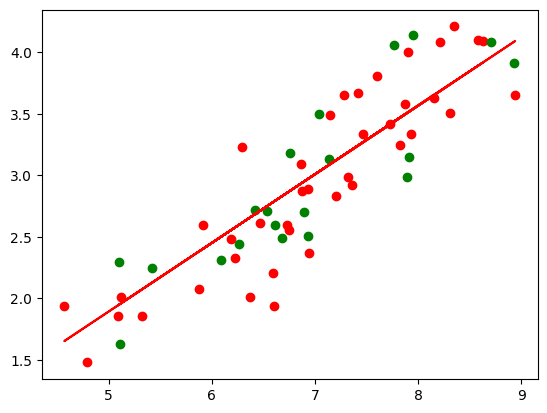

In [22]:
plt.scatter(X_test, Y_test, color='red')
plt.scatter(X_train[:20], Y_train[:20], color='green')
plt.plot(X_test, my_model.predict(X_test), 'red')

plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = my_model.predict(X_test)


print("MAE", mean_absolute_error(Y_test, y_pred))
print("MSE", mean_squared_error(Y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(Y_test, y_pred)))
print("R2", r2_score(Y_test, y_pred))

MAE 0.2884710931878174
MSE 0.12129235313495523
RMSE 0.3482705171773161
R2 0.7807301475103842


In [35]:
# Finding the adjusted R2 score

n = X_test.shape[0]    # Number of input data
k = 1                  # Number of parameters here it is only one that is cgpa

r2_adjusted = 1 - ((1 - r2_score(Y_test, y_pred))*(n-1)/(n-k-1))
print(r2_adjusted)

0.7749598882343417


In [48]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(len(new_df))

print(new_df.head())

new_df = new_df[['cgpa', 'random_feature', 'package']]
print(new_df.head())

   cgpa  package  random_feature
0  6.89     3.26        0.928292
1  5.12     1.98        0.351599
2  7.82     3.25        0.442168
3  7.42     3.67        0.355407
4  6.94     3.57        0.230473
   cgpa  random_feature  package
0  6.89        0.928292     3.26
1  5.12        0.351599     1.98
2  7.82        0.442168     3.25
3  7.42        0.355407     3.67
4  6.94        0.230473     3.57


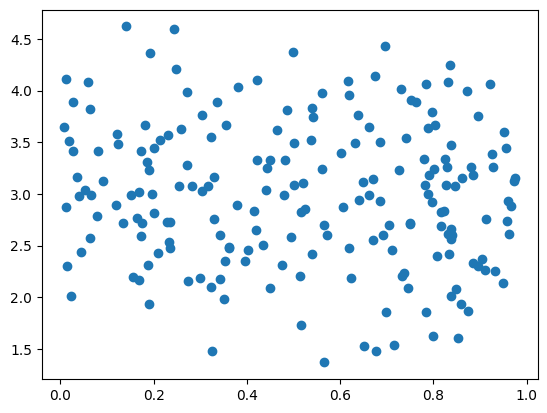

In [52]:
plt.scatter(new_df['random_feature'], new_df['package'])

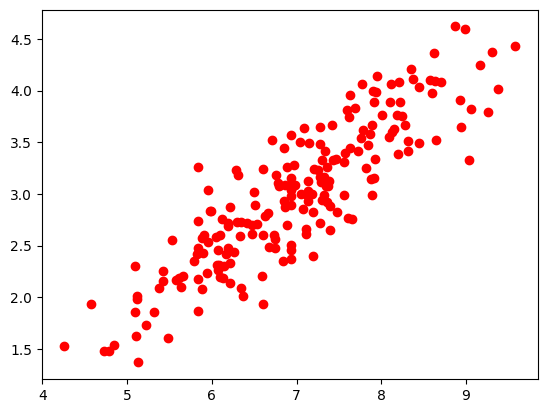

In [54]:
plt.scatter(new_df['cgpa'], new_df['package'], color='red')

In [ ]:
X = new_df.iloc[:, 0:2]
Y = new_df.iloc[:, -1]

In [62]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(X_train.head())
print(len(X_train))
print(len(X_test))
print(len(X))

     cgpa  random_feature
137  7.14        0.972651
163  8.93        0.751597
111  5.42        0.931537
123  5.10        0.895271
109  7.77        0.783554
160
40
200


In [70]:
model_2 = LinearRegression()
model_2.fit(X_train, Y_train)
print(model_2.predict(X_test))

[3.89227487 3.09191305 2.38071533 2.56996218 1.64971226 1.77468422
 2.06908265 2.93170273 3.766065   2.9432578  4.09816706 3.50741471
 2.97541619 2.40081927 3.19365021 3.4680176  1.94179474 3.24591218
 2.9714171  3.42287042 2.56114645 3.16406194 2.85505618 3.12120092
 3.69028133 2.86623871 3.49982345 3.3447336  3.91780476 1.95682716
 3.65436765 3.20706005 3.74656238 2.79044754 2.77824748 3.26806781
 3.52526471 2.61749671 2.66417583 2.70849176]


In [73]:
y_pred = model_2.predict(X_test)
print(r2_score(Y_test, y_pred))


r2_adjusted = 1 - ((1 - r2_score(Y_test, y_pred))*(n-1)/(n-k-1))
print(r2_adjusted)

0.7807740624286139
0.7750049588083143
